In [ ]:
"""
BIOMARKER CHARACTERIZATION — GSE45827
SHAP / KEGG / GO / Reactome enrichment / expression heatmap
====================================================================

DESIGN PRINCIPLE:
  This notebook does ZERO model fitting and ZERO feature selection.
  Everything below is derived from two artifacts already produced
  elsewhere in the pipeline:

    1. frozen_selector.pkl / frozen_scaler.pkl / frozen_model.pkl /
       frozen_label_encoder.pkl / selected_probe_ids.pkl
           <-- created in 04_external_validation_GSE21653
           (fit ONCE on all 130 GSE45827 samples; never refit here)

    2. reference_46gene_panel.csv
           <-- created in 03_feature_stability_analysis
           (SHAP importance ranking derived directly from the frozen
           model above, so the panel and the model are guaranteed
           consistent by construction)

"""

In [1]:
# ============================================================
# — Install dependencies (Colab)
# ============================================================
!pip install GEOparse xgboost shap gseapy mygene seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.9/689.9 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 4.0 MB/s eta 0:00:00


In [2]:
# ============================================================
# — Imports
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import pickle

import GEOparse
import matplotlib.pyplot as plt
import mygene
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import gseapy as gp
from scipy.stats import zscore

VALID_SUBTYPES = ["Basal", "Her2", "Luminal A", "Luminal B"]

In [3]:
# ============================================================
# — Load frozen artifacts (from 04_external_validation_GSE21653)

# ============================================================

from google.colab import files
files.upload()

ARTIFACT_DIR = "."  # <-- point this at wherever the frozen_*.pkl files live

with open(f"{ARTIFACT_DIR}/frozen_selector.pkl", "rb") as f:
    frozen_selector = pickle.load(f)
with open(f"{ARTIFACT_DIR}/frozen_scaler.pkl", "rb") as f:
    frozen_scaler = pickle.load(f)
with open(f"{ARTIFACT_DIR}/frozen_model.pkl", "rb") as f:
    frozen_model = pickle.load(f)
with open(f"{ARTIFACT_DIR}/frozen_label_encoder.pkl", "rb") as f:
    frozen_le = pickle.load(f)
with open(f"{ARTIFACT_DIR}/selected_probe_ids.pkl", "rb") as f:
    frozen_probe_ids = pickle.load(f)

# Spot-check — confirms this is the Supplementary Table S1 model, not a
# stray refit
print(f"Frozen model uses {len(frozen_probe_ids)} probes.")
print(
    "Frozen model params (spot check):",
    frozen_model.get_params()["n_estimators"],
    frozen_model.get_params()["max_depth"],
    frozen_model.get_params()["learning_rate"],
)
print("Classes:", list(frozen_le.classes_))

Saving frozen_label_encoder.pkl to frozen_label_encoder.pkl
Saving frozen_model.pkl to frozen_model.pkl
Saving frozen_scaler.pkl to frozen_scaler.pkl
Saving frozen_selector.pkl to frozen_selector.pkl
Saving selected_probe_ids.pkl to selected_probe_ids.pkl
Frozen model uses 300 probes.
Frozen model params (spot check): 100 6 0.3
Classes: ['Basal', 'Her2', 'Luminal A', 'Luminal B']


In [4]:
# ============================================================
# — Load raw GSE45827 expression matrix + labels
# (needed to index the frozen model's probes and for the heatmap;
# NOT used to fit anything)
# ============================================================


def load_gse45827():
    gse = GEOparse.get_GEO(geo="GSE45827", destdir="./geo_cache")
    rows, labels, sample_ids = [], [], []
    for gsm_name, gsm in gse.gsms.items():
        chars = gsm.metadata.get("characteristics_ch1", [])
        subtype = None
        for c in chars:
            if c.lower().startswith("tumor subtype"):
                subtype = c.split(":", 1)[1].strip()
        if subtype not in VALID_SUBTYPES:
            continue
        expr = gsm.table.set_index("ID_REF")["VALUE"]
        rows.append(expr)
        labels.append(subtype)
        sample_ids.append(gsm_name)
    X = pd.DataFrame(rows, index=sample_ids)
    y = pd.Series(labels, index=sample_ids, name="subtype")
    return X, y


print("Loading GSE45827...")
X, y = load_gse45827()
print(f"Samples: {X.shape[0]}, probes: {X.shape[1]}")
print(y.value_counts())

03-Aug-2026 06:02:47 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz to ./geo_cache/GSE45827_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz to ./geo_cache/GSE45827_family.soft.gz


Loading GSE45827...


100%|██████████| 40.1M/40.1M [00:05<00:00, 7.96MB/s]
03-Aug-2026 06:02:54 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
03-Aug-2026 06:02:54 DEBUG downloader - Moving /tmp/tmp7ancso3d to /content/geo_cache/GSE45827_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp7ancso3d to /content/geo_cache/GSE45827_family.soft.gz
03-Aug-2026 06:02:54 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz
03-Aug-2026 06:02:54 INFO GEOparse - Parsing ./geo_cache/GSE45827_family.soft.gz: 
INFO:GEOparse:Parsing ./geo_cache/GSE45827_family.soft.gz: 
03-Aug-2026 06:02:54 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
03-Aug-2026 06:02:54 DEBUG GEOparse - SERIES: GSE45827
DEBUG:GEOparse:SERIES: GSE45827
03-Aug-2026 06:02:54 DEBUG GEOparse - PLATFORM: GPL570
DE

Samples: 130, probes: 29873
subtype
Basal        41
Her2         30
Luminal B    30
Luminal A    29
Name: count, dtype: int64


In [5]:
# ============================================================
# — Load the reference 43-gene panel
# (from 03_feature_stability_analysis; SHAP-derived from THIS SAME
# frozen_model, so it is guaranteed consistent with Cell 3)
# ============================================================
from google.colab import files
files.upload()   # reference_46gene_panel.csv, if not already present

panel_df = pd.read_csv(f"{ARTIFACT_DIR}/reference_46gene_panel.csv")
print(f"Loaded {len(panel_df)} probe entries from the reference panel.")

n_unique_genes = panel_df["gene_symbol"].nunique()
print(f"Resolves to {n_unique_genes} unique gene symbols.")
panel_df.sort_values("shap_importance", ascending=False).head(10)

Saving reference_46gene_panel.csv to reference_46gene_panel.csv
Loaded 50 probe entries from the reference panel.
Resolves to 43 unique gene symbols.


,probe_id,gene_symbol,shap_importance,rank
0,218211_s_at,MLPH,0.359784,1
1,204092_s_at,AURKA,0.267676,2
2,210930_s_at,ERBB2,0.267163,3
3,205225_at,ESR1,0.234532,4
4,234354_x_at,ERBB2,0.195110,5
5,232322_x_at,STARD10,0.174972,6
6,229150_at,NaN,0.122322,7
7,200934_at,DEK,0.108547,8
8,201710_at,MYBL2,0.089683,9
9,202991_at,STARD3,0.089151,10


In [6]:
# ============================================================
# — Gene-symbol labels for ALL 300 frozen probes
# (the panel CSV only has symbols for its top ~50; the frozen model
# uses 300 -- this fills in the rest so the SHAP plot below has real
# labels for every feature, not just the reported panel genes)
# ============================================================

known_symbol_map = dict(zip(panel_df["probe_id"], panel_df["gene_symbol"]))
probes_needing_lookup = [p for p in frozen_probe_ids if p not in known_symbol_map]

if probes_needing_lookup:
    mg = mygene.MyGeneInfo()
    query_res = mg.querymany(
        probes_needing_lookup, scopes="reporter", fields="symbol", species="human"
    )
    for r in query_res:
        if "symbol" in r:
            known_symbol_map[r["query"]] = r["symbol"]


def resolve_label(probe_id):
    """Gene symbol if known, else fall back to the raw probe ID."""
    sym = known_symbol_map.get(probe_id)
    if sym is None or (isinstance(sym, float) and pd.isna(sym)):
        return probe_id
    return sym


shap_feature_labels = [resolve_label(p) for p in frozen_probe_ids]
print(f"Labeled {len(shap_feature_labels)} features "
      f"({sum(1 for l in shap_feature_labels if l not in frozen_probe_ids)} resolved to gene symbols).")

INFO:biothings.client:querying 1-250 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Labeled 300 features (278 resolved to gene symbols).


In [7]:
# ============================================================
# — Build the frozen model's exact input space
# (same 300 probes, same scaler — NOT refit)
# ============================================================

X_frozen_selected = X[frozen_probe_ids].values
X_frozen_scaled = frozen_scaler.transform(X_frozen_selected)
y_encoded_full = frozen_le.transform(y)

print(f"Frozen input matrix: {X_frozen_scaled.shape}")

Frozen input matrix: (130, 300)


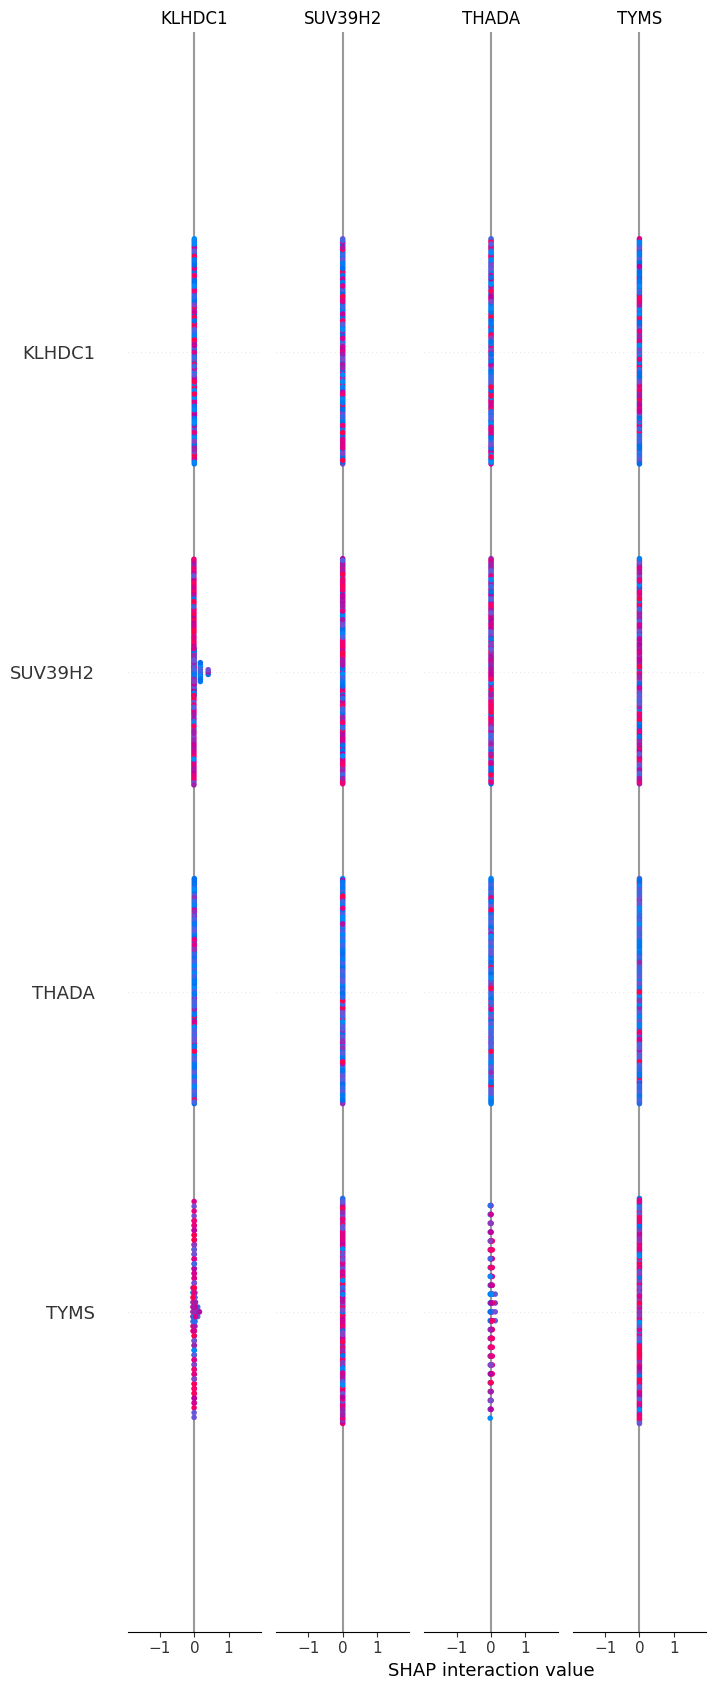

In [8]:
# ============================================================
# — SHAP on the FROZEN model (properly labeled)
# ============================================================

explainer = shap.TreeExplainer(frozen_model)
shap_values = explainer.shap_values(X_frozen_scaled)

shap.summary_plot(
    shap_values,
    X_frozen_scaled,
    feature_names=shap_feature_labels,
    class_names=list(frozen_le.classes_),
    max_display=20,
    show=False,
)
plt.tight_layout()
plt.savefig("shap_summary_frozen_model.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# ============================================================
# — KEGG + GO enrichment (panel genes only, as reported)
# ============================================================

gene_symbols = panel_df["gene_symbol"].dropna().unique().tolist()
print(f"Genes for enrichment: {len(gene_symbols)}")

enr_kegg_go = gp.enrichr(
    gene_list=gene_symbols,
    gene_sets=["KEGG_2021_Human", "GO_Biological_Process_2023"],
    organism="human",
    outdir=None,
    cutoff=0.5,
)

kegg_go_df = enr_kegg_go.results.sort_values("Adjusted P-value")
print(kegg_go_df[kegg_go_df["Adjusted P-value"] < 0.05][["Gene_set", "Term", "Overlap", "Adjusted P-value"]].head(15))

Genes for enrichment: 43
                      Gene_set  \
62  GO_Biological_Process_2023   
63  GO_Biological_Process_2023   
65  GO_Biological_Process_2023   
66  GO_Biological_Process_2023   
68  GO_Biological_Process_2023   
64  GO_Biological_Process_2023   
67  GO_Biological_Process_2023   

                                                 Term Overlap  \
62  Regulation Of Mitotic Cell Cycle Phase Transit...    4/86   
63    DNA Integrity Checkpoint Signaling (GO:0031570)    3/42   
65  Proteasome-Mediated Ubiquitin-Dependent Protei...   5/319   
66  DNA Replication Checkpoint Signaling (GO:0000076)    2/17   
68             Regulation Of Cytokinesis (GO:0032465)    3/80   
64       Regulation Of Exit From Mitosis (GO:0007096)    2/14   
67  Regulation Of Cell Cycle G2/M Phase Transition...    2/18   

    Adjusted P-value  
62          0.017472  
63          0.025308  
65          0.048891  
66          0.048891  
68          0.048891  
64          0.048891  
67          0.048891

In [10]:
# ============================================================
# — Reactome enrichment (panel genes only)
# ============================================================

enr_reactome = gp.enrichr(
    gene_list=gene_symbols,
    gene_sets=["Reactome_2022"],
    organism="human",
    outdir=None,
    cutoff=0.5,
)

reactome_df = enr_reactome.results.sort_values("Adjusted P-value")
print(reactome_df[reactome_df["Adjusted P-value"] < 0.05][["Gene_set", "Term", "Overlap", "Adjusted P-value"]].head(15))

# Combine all three gene-set libraries into one frame for the plots below
enrichment_all = pd.concat([enr_kegg_go.results, enr_reactome.results], ignore_index=True)

         Gene_set                                               Term Overlap  \
0   Reactome_2022                           Cell Cycle R-HSA-1640170  11/654   
1   Reactome_2022                    Cell Cycle, Mitotic R-HSA-69278  10/523   
2   Reactome_2022  Mitotic G1 Phase And G1/S Transition R-HSA-453279   6/147   
3   Reactome_2022                        DNA Replication R-HSA-69306   6/155   
4   Reactome_2022  Transcriptional Regulation By AP-2 (TFAP2) Fam...    4/36   
5   Reactome_2022                                S Phase R-HSA-69242   6/161   
6   Reactome_2022                 Cell Cycle Checkpoints R-HSA-69620   7/271   
7   Reactome_2022                       Synthesis Of DNA R-HSA-69239   5/119   
8   Reactome_2022         DNA Replication Pre-Initiation R-HSA-69002   5/127   
9   Reactome_2022                        G1/S Transition R-HSA-69206   5/129   
10  Reactome_2022  CDK-mediated Phosphorylation And Removal Of Cd...    4/72   
11  Reactome_2022                      G

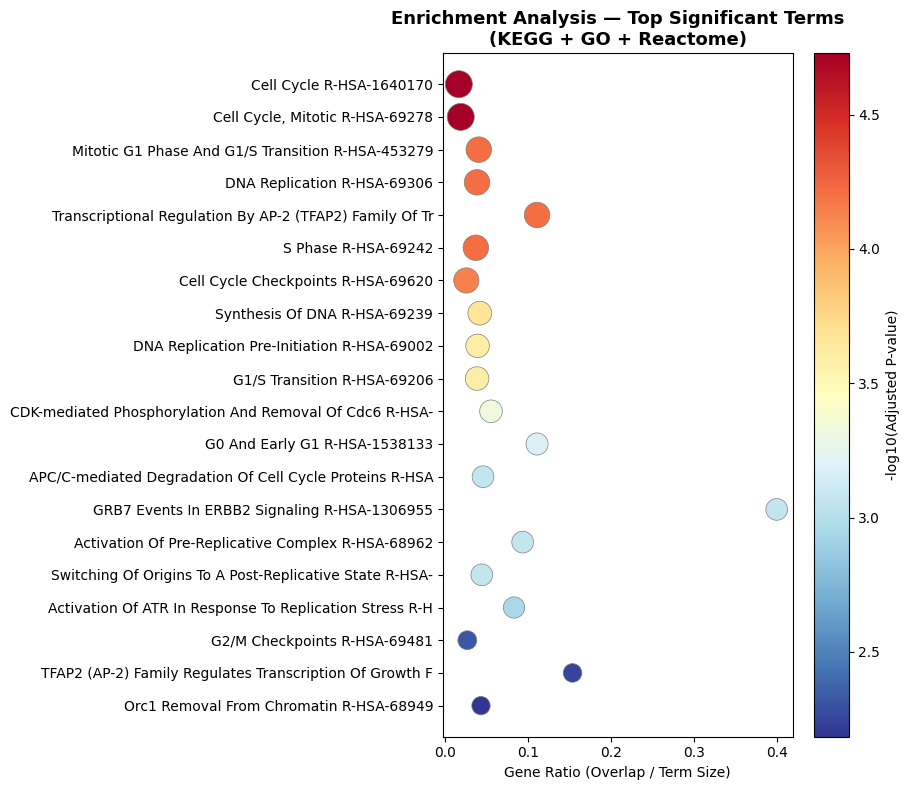

In [11]:
# ============================================================
# — Enrichment dot plot (KEGG + GO + Reactome combined)
# ============================================================

df_sig = enrichment_all[enrichment_all["Adjusted P-value"] < 0.05].copy()

df_sig["overlap_ratio"] = df_sig["Overlap"].apply(
    lambda x: int(x.split("/")[0]) / int(x.split("/")[1])
)
df_sig["-log10(FDR)"] = -np.log10(df_sig["Adjusted P-value"])
df_sig["Term_short"] = df_sig["Term"].str.slice(0, 55)

df_plot = df_sig.sort_values("Adjusted P-value").head(20)

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(
    df_plot["overlap_ratio"],
    df_plot["Term_short"],
    s=df_plot["-log10(FDR)"] * 80,
    c=df_plot["-log10(FDR)"],
    cmap="RdYlBu_r",
    edgecolors="grey",
    linewidths=0.5,
)

plt.colorbar(scatter, ax=ax, label="-log10(Adjusted P-value)")
ax.set_xlabel("Gene Ratio (Overlap / Term Size)")
ax.set_title("Enrichment Analysis — Top Significant Terms\n(KEGG + GO + Reactome)",
             fontsize=13, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("enrichment_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

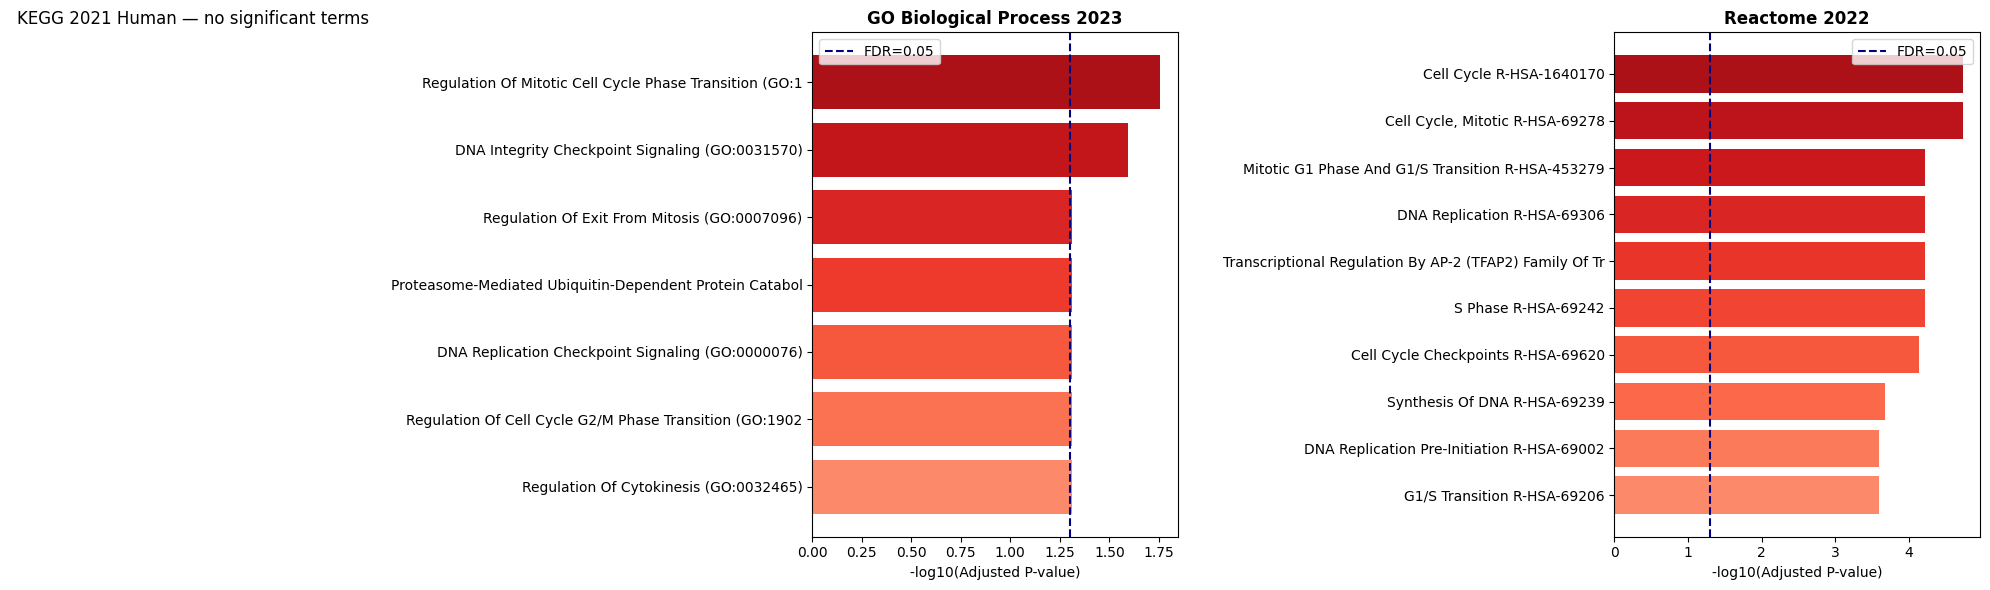

In [12]:
# ============================================================
# — Enrichment bar plots, one panel per gene-set library
# ============================================================

gene_set_names = ["KEGG_2021_Human", "GO_Biological_Process_2023", "Reactome_2022"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, gs in zip(axes, gene_set_names):
    sub = df_sig[df_sig["Gene_set"] == gs].sort_values("Adjusted P-value").head(10)
    if sub.empty:
        ax.set_title(f"{gs.replace('_', ' ')} — no significant terms")
        ax.axis("off")
        continue
    ax.barh(
        sub["Term_short"],
        -np.log10(sub["Adjusted P-value"]),
        color=plt.cm.Reds(np.linspace(0.4, 0.85, len(sub)))[::-1],
    )
    ax.axvline(x=-np.log10(0.05), color="navy", linestyle="--", label="FDR=0.05")
    ax.set_xlabel("-log10(Adjusted P-value)")
    ax.set_title(gs.replace("_", " "), fontweight="bold")
    ax.invert_yaxis()
    ax.legend()

plt.tight_layout()
plt.savefig("enrichment_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

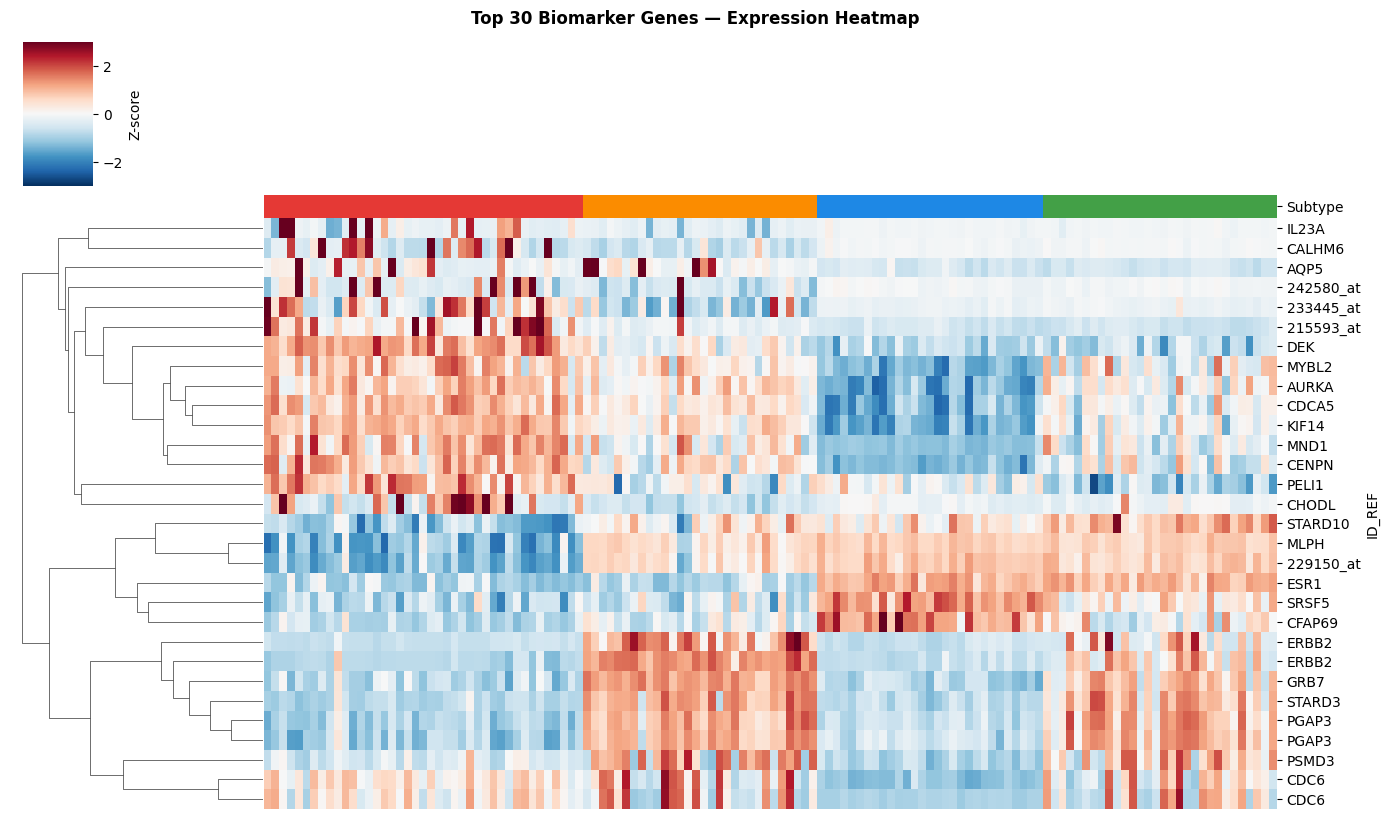

In [13]:
# ============================================================
# — Expression heatmap, top 30 panel genes (labeled by symbol)
# ============================================================

palette = {
    "Basal":     "#E53935",
    "Her2":      "#FB8C00",
    "Luminal A": "#1E88E5",
    "Luminal B": "#43A047",
}

top30 = panel_df.sort_values("shap_importance", ascending=False).head(30)
top30_probes = top30["probe_id"].tolist()
top30_labels = [resolve_label(p) for p in top30_probes]

heatmap_df = X[top30_probes].copy()
heatmap_df["Subtype"] = y.values
heatmap_df = heatmap_df.sort_values("Subtype")

expr_matrix = heatmap_df[top30_probes].apply(zscore)
subtype_colors = heatmap_df["Subtype"].map(palette)

g = sns.clustermap(
    expr_matrix.T,
    col_colors=subtype_colors,
    cmap="RdBu_r",
    figsize=(14, 8),
    col_cluster=False,
    row_cluster=True,
    center=0,
    vmin=-3, vmax=3,
    yticklabels=top30_labels,   # <-- real gene symbols, not probe IDs
    xticklabels=False,
    cbar_kws={"label": "Z-score"},
)
plt.suptitle("Top 30 Biomarker Genes — Expression Heatmap", y=1.02, fontweight="bold")
plt.savefig("biomarker_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# ============================================================
# — Save outputs for manuscript / GitHub repo
# ============================================================

enrichment_all.to_csv("enrichment_results_all.csv", index=False)
